<a href="https://colab.research.google.com/github/MDAnsaar25/Mushroom-Classification-and-Analysis/blob/main/Mushroom_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style('dark')

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn import metrics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
mushroom= pd.read_csv('/content/drive/MyDrive/Data Sets/mushrooms.csv')

In [ ]:
mushroom.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
mushroom.tail(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


In [ ]:
mushroom.duplicated().sum()

np.int64(0)

In [ ]:
mushroom.isnull().sum() #Checking null values

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


In [ ]:
mushroom.shape

(8124, 23)

In [ ]:
mushroom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [ ]:
mushroom['class'].value_counts().to_frame()   #number of edible(e)and  poisonous(p) Mashrooms

,count
class,
e,4208
p,3916


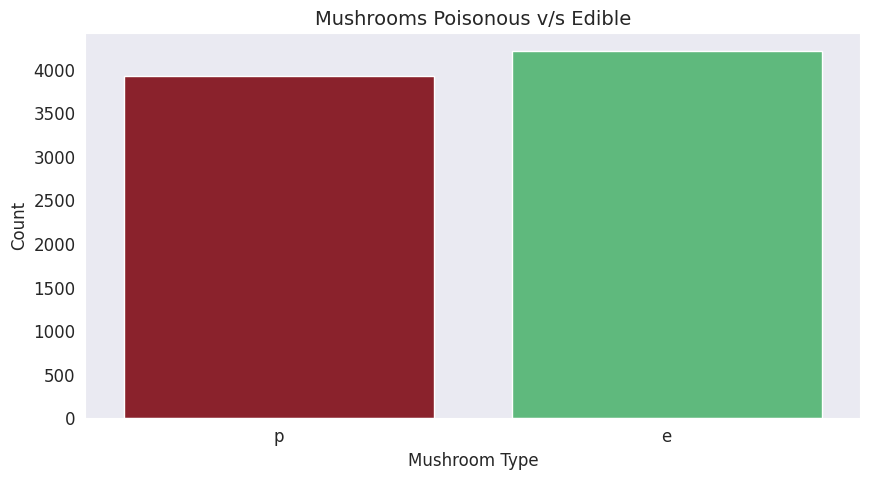

In [ ]:
plt.figure(figsize=(10,5))
plt.title('Mushrooms Poisonous v/s Edible', fontsize=14)
sns.countplot(x="class", data=mushroom, palette=('#9b111e','#50c878'))
plt.xlabel("Mushroom Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

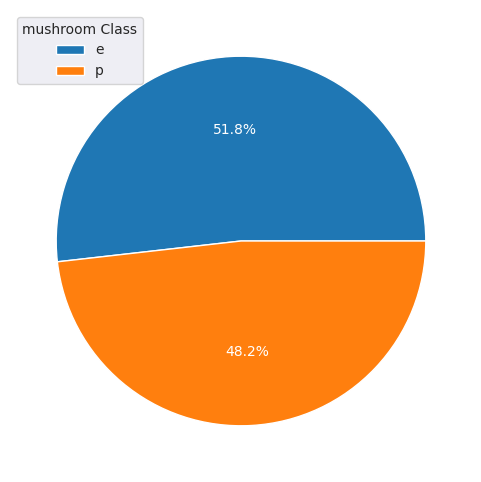

In [ ]:
# pie chart

# prepare the data for plotting
# create a dictionary of classes and their totals
d = mushroom["class"].value_counts().to_dict()

# instanciate the figure
fig = plt.figure(figsize = (18, 6))
ax = fig.add_subplot()

# plot the data using matplotlib
ax.pie(d.values(), # pass the values from our dictionary
       labels = d.keys(), # pass the labels from our dictonary
       autopct = '%1.1f%%', # specify the format to be plotted %age
       textprops = {'fontsize': 10, 'color' : "white"} # change the font size and the color of the numbers inside the pie
      )
# set the legend and add a title to the legend
ax.legend(loc = "upper left", title = "mushroom Class")
plt.show()

In [ ]:
mushroom.groupby(['cap-shape'])['class'].value_counts().to_frame()

count
cap-shape class       
b         e        404
          p         48
c         p          4
f         e       1596
          p       1556
k         p        600
          e        228
s         e         32
x         e       1948
          p       1708

In [ ]:
mushroom.groupby(['cap-surface'])['class'].value_counts().to_frame()

count
cap-surface class       
f           e       1560
            p        760
g           p          4
s           p       1412
            e       1144
y           p       1740
            e       1504

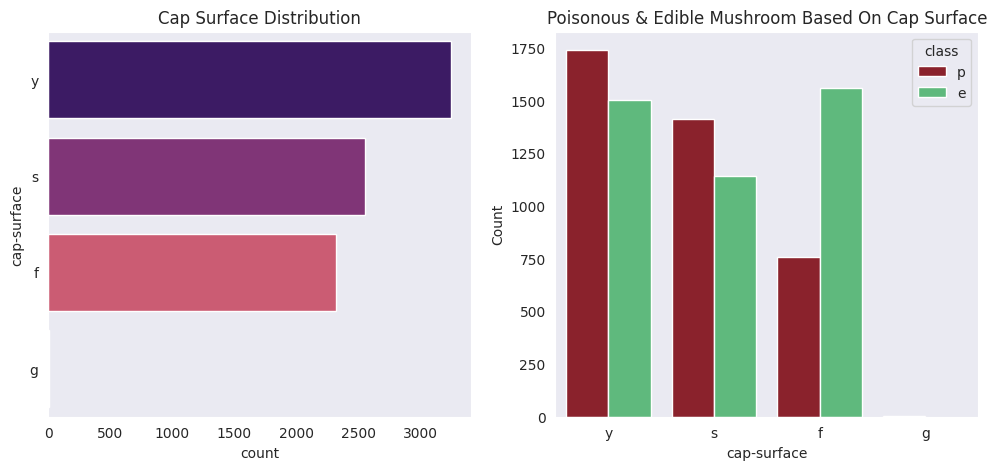

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['cap-surface'], ax=axarr[0], order=mushroom['cap-surface'].value_counts().index, palette="magma").set_title('Cap Surface Distribution')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Cap Surface')
b = sns.countplot(x="cap-surface", data=mushroom, hue="class", order=mushroom['cap-surface'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

In [ ]:
mushroom.groupby(['cap-color'])['class'].value_counts().to_frame()

count
cap-color class       
b         p        120
          e         48
c         e         32
          p         12
e         p        876
          e        624
g         e       1032
          p        808
n         e       1264
          p       1020
p         p         88
          e         56
r         e         16
u         e         16
w         e        720
          p        320
y         p        672
          e        400

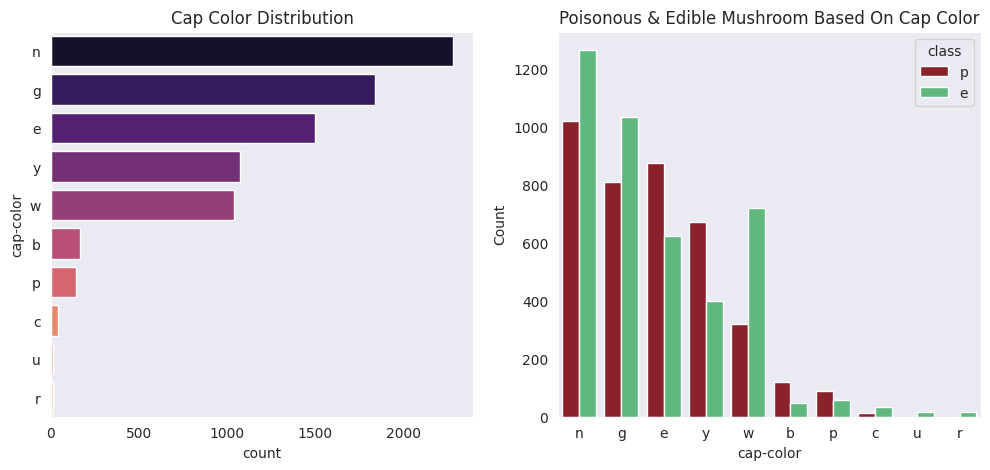

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['cap-color'], ax=axarr[0], order=mushroom['cap-color'].value_counts().index, palette="magma").set_title('Cap Color Distribution')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Cap Color')
b = sns.countplot(x="cap-color", data=mushroom, hue="class", order=mushroom['cap-color'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

In [ ]:
mushroom.groupby(['bruises'])['class'].value_counts().to_frame()

count
bruises class       
f       p       3292
        e       1456
t       e       2752
        p        624

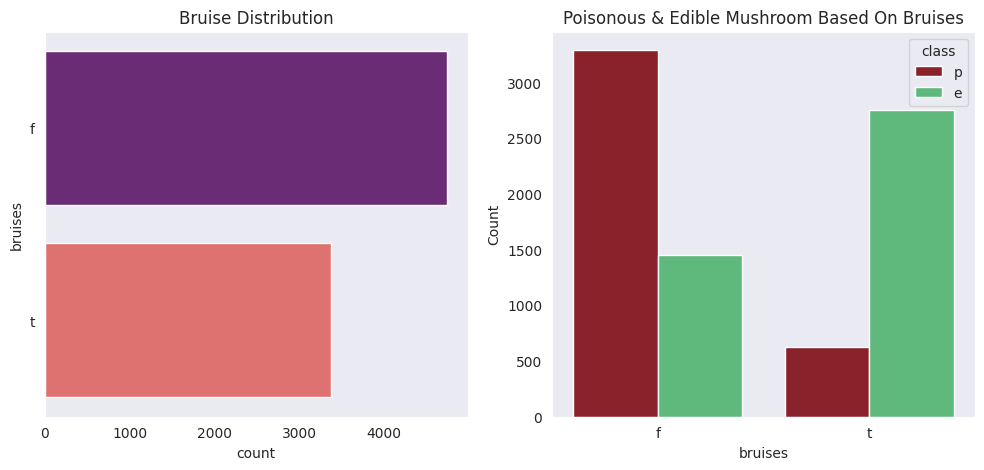

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['bruises'], ax=axarr[0], order=mushroom['bruises'].value_counts().index, palette="magma").set_title('Bruise Distribution')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Bruises')
b = sns.countplot(x="bruises", data=mushroom, hue="class", order=mushroom['bruises'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Odor

In [ ]:
mushroom.groupby(['odor'])['class'].value_counts().to_frame()

count
odor class       
a    e        400
c    p        192
f    p       2160
l    e        400
m    p         36
n    e       3408
     p        120
p    p        256
s    p        576
y    p        576

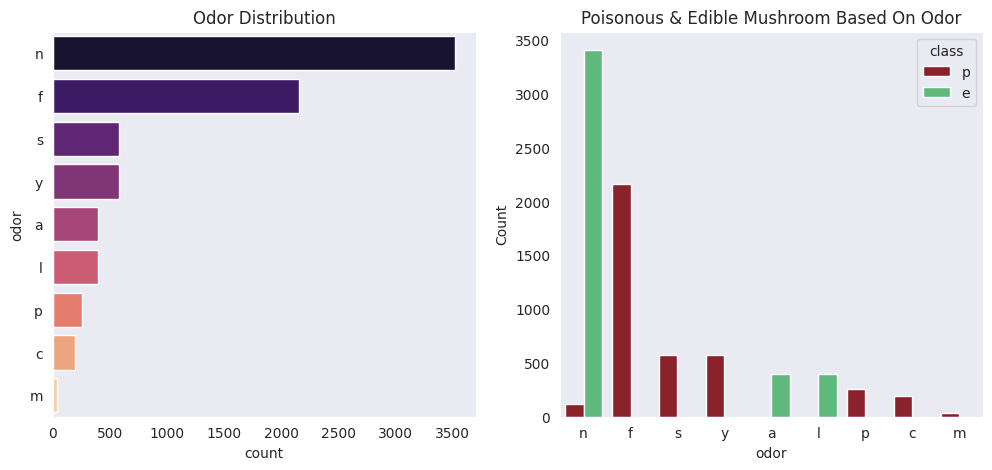

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['odor'], ax=axarr[0], order=mushroom['odor'].value_counts().index, palette="magma").set_title('Odor Distribution')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Odor')
b = sns.countplot(x="odor", data=mushroom, hue="class", order=mushroom['odor'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Gill Attachment

In [ ]:
mushroom.groupby(['gill-attachment'])['class'].value_counts().to_frame()

count
gill-attachment class       
a               e        192
                p         18
f               e       4016
                p       3898

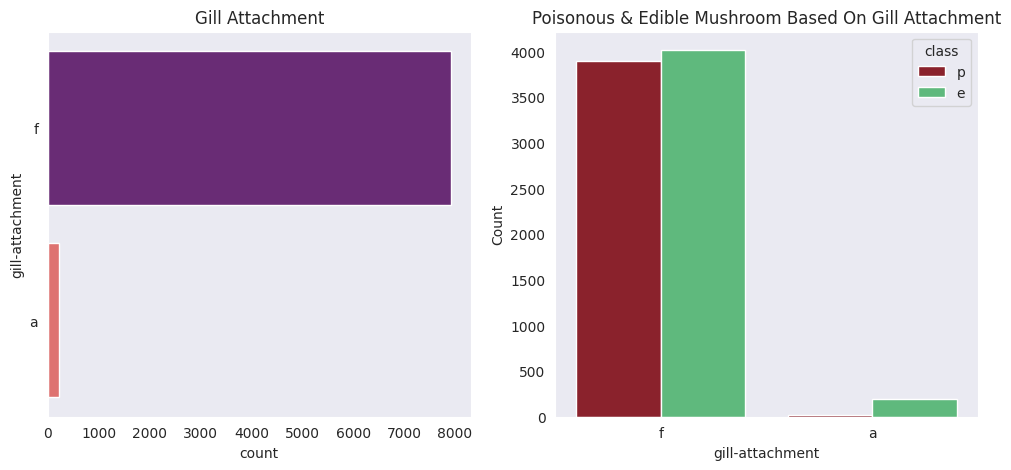

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['gill-attachment'], ax=axarr[0], order=mushroom['gill-attachment'].value_counts().index, palette="magma").set_title('Gill Attachment')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Gill Attachment')
b = sns.countplot(x="gill-attachment", data=mushroom, hue="class", order=mushroom['gill-attachment'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Gill Spacing

In [ ]:
mushroom.groupby(['gill-spacing'])['class'].value_counts().to_frame()

count
gill-spacing class       
c            p       3804
             e       3008
w            e       1200
             p        112

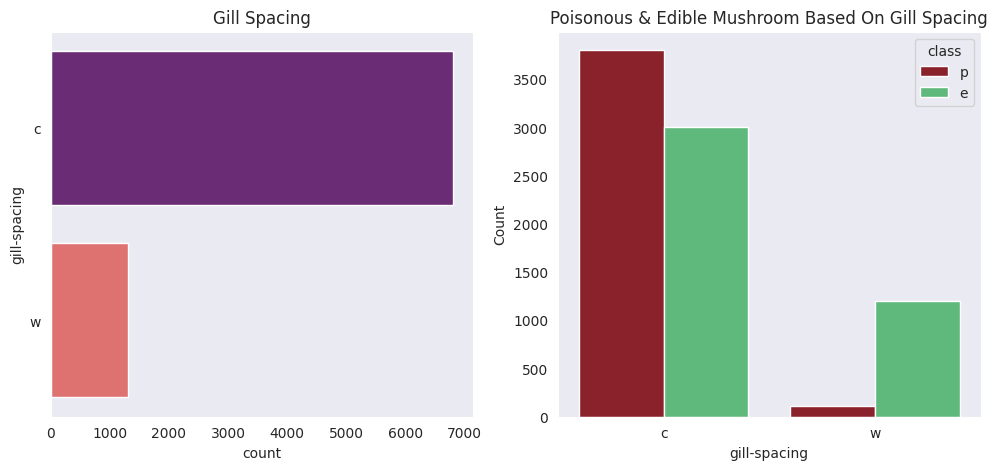

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['gill-spacing'], ax=axarr[0], order=mushroom['gill-spacing'].value_counts().index, palette="magma").set_title('Gill Spacing')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Gill Spacing')
b = sns.countplot(x="gill-spacing", data=mushroom, hue="class", order=mushroom['gill-spacing'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Gill Size

In [ ]:
mushroom.groupby(['gill-size'])['class'].value_counts().to_frame()

count
gill-size class       
b         e       3920
          p       1692
n         p       2224
          e        288

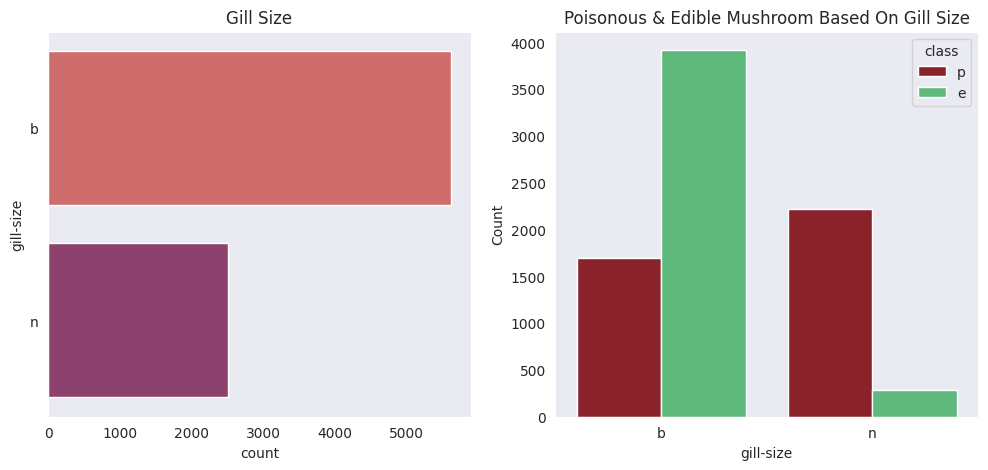

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['gill-size'], ax=axarr[0], order=mushroom['gill-size'].value_counts().index, palette="flare").set_title('Gill Size')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Gill Size')
b = sns.countplot(x="gill-size", data=mushroom, hue="class", order=mushroom['gill-size'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Gill Color

In [ ]:
mushroom.groupby(['gill-color'])['class'].value_counts().to_frame()

count
gill-color class       
b          p       1728
e          e         96
g          p        504
           e        248
h          p        528
           e        204
k          e        344
           p         64
n          e        936
           p        112
o          e         64
p          e        852
           p        640
r          p         24
u          e        444
           p         48
w          e        956
           p        246
y          e         64
           p         22

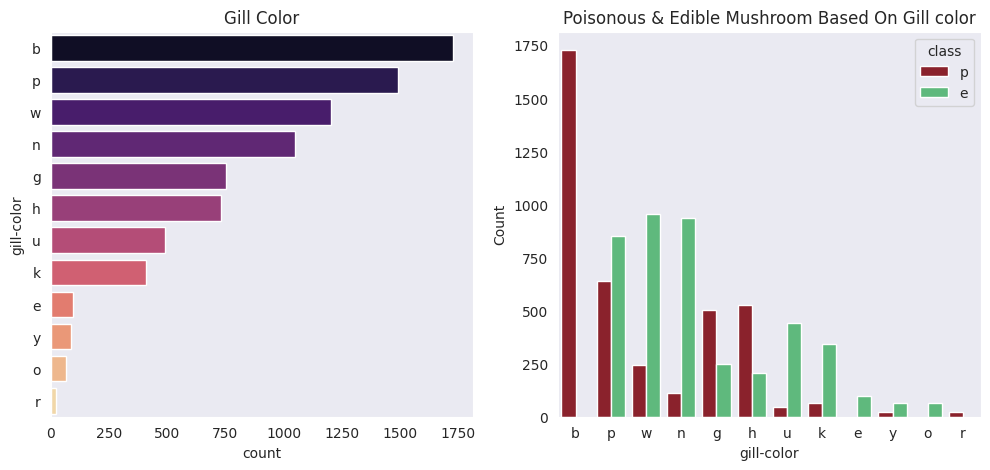

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['gill-color'], ax=axarr[0], order=mushroom['gill-color'].value_counts().index, palette="magma").set_title('Gill Color')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Gill color')
b = sns.countplot(x="gill-color", data=mushroom, hue="class", order=mushroom['gill-color'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Stalk Shape

In [ ]:
mushroom.groupby(['stalk-shape'])['class'].value_counts().to_frame()

count
stalk-shape class       
e           p       1900
            e       1616
t           e       2592
            p       2016

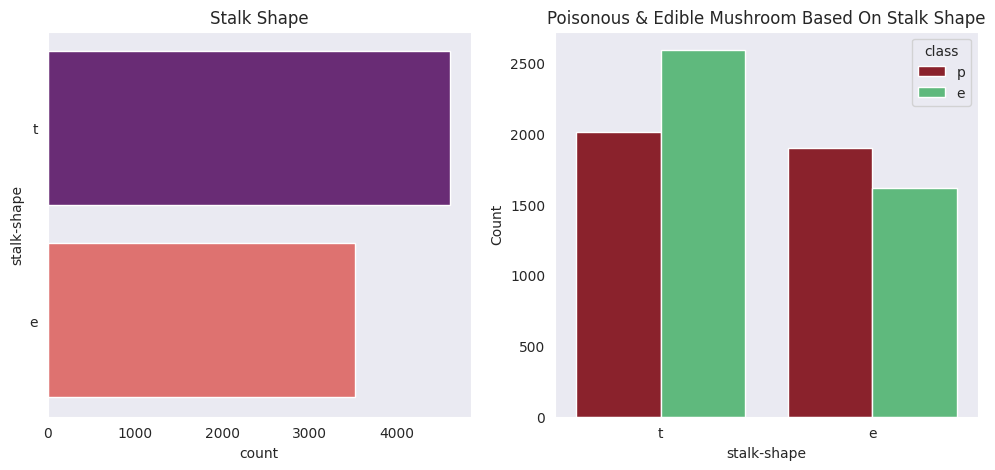

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['stalk-shape'], ax=axarr[0], order=mushroom['stalk-shape'].value_counts().index, palette="magma").set_title('Stalk Shape')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Stalk Shape')
b = sns.countplot(x="stalk-shape", data=mushroom, hue="class", order=mushroom['stalk-shape'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Stalk Surface Above Ring

In [ ]:
mushroom.groupby(['stalk-surface-above-ring'])['class'].value_counts().to_frame()

count
stalk-surface-above-ring class       
f                        e        408
                         p        144
k                        p       2228
                         e        144
s                        e       3640
                         p       1536
y                        e         16
                         p          8

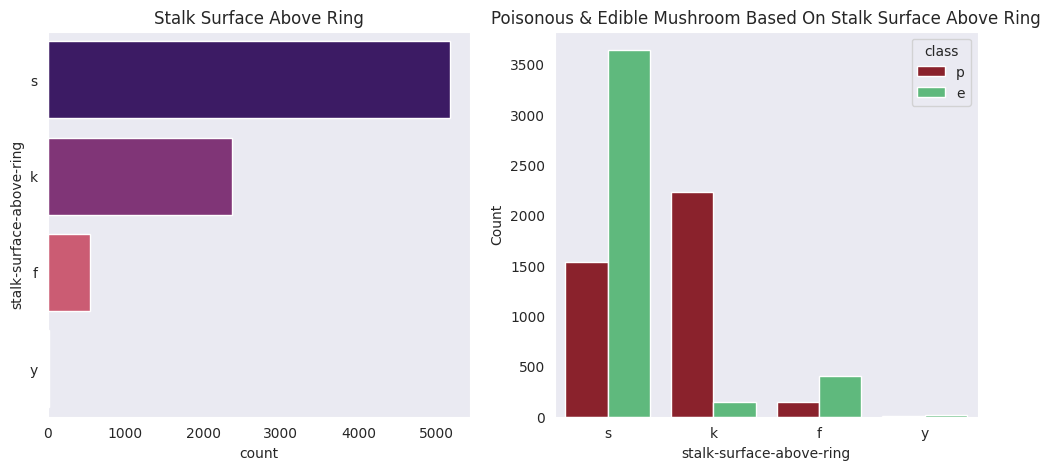

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['stalk-surface-above-ring'], ax=axarr[0], order=mushroom['stalk-surface-above-ring'].value_counts().index, palette="magma").set_title('Stalk Surface Above Ring')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Stalk Surface Above Ring')
b = sns.countplot(x="stalk-surface-above-ring", data=mushroom, hue="class", order=mushroom['stalk-surface-above-ring'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Stalk Surface Below Ring

In [ ]:
mushroom.groupby(['stalk-surface-below-ring'])['class'].value_counts().to_frame()

count
stalk-surface-below-ring class       
f                        e        456
                         p        144
k                        p       2160
                         e        144
s                        e       3400
                         p       1536
y                        e        208
                         p         76

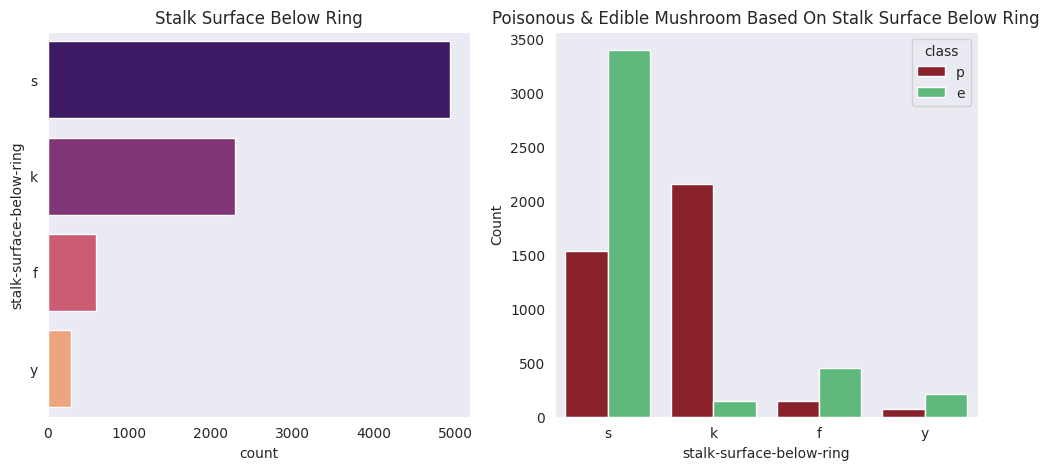

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['stalk-surface-below-ring'], order=mushroom['stalk-surface-below-ring'].value_counts().index, ax=axarr[0], palette="magma").set_title('Stalk Surface Below Ring')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Stalk Surface Below Ring')
b = sns.countplot(x="stalk-surface-below-ring", data=mushroom, hue="class", order=mushroom['stalk-surface-below-ring'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Stalk Color Above Ring

In [ ]:
mushroom.groupby(['stalk-color-above-ring'])['class'].value_counts().to_frame()

count
stalk-color-above-ring class       
b                      p        432
c                      p         36
e                      e         96
g                      e        576
n                      p        432
                       e         16
o                      e        192
p                      p       1296
                       e        576
w                      e       2752
                       p       1712
y                      p          8

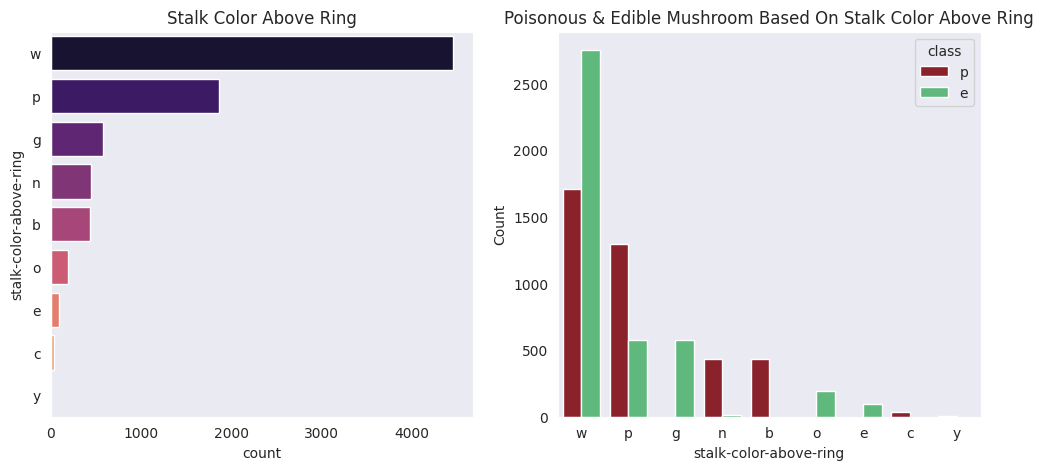

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['stalk-color-above-ring'], ax=axarr[0], order=mushroom['stalk-color-above-ring'].value_counts().index, palette="magma").set_title('Stalk Color Above Ring')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Stalk Color Above Ring')
b = sns.countplot(x="stalk-color-above-ring", data=mushroom, hue="class", order=mushroom['stalk-color-above-ring'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Stalk Color Below Ring

In [ ]:
mushroom.groupby(['stalk-color-below-ring'])['class'].value_counts().to_frame()

count
stalk-color-below-ring class       
b                      p        432
c                      p         36
e                      e         96
g                      e        576
n                      p        448
                       e         64
o                      e        192
p                      p       1296
                       e        576
w                      e       2704
                       p       1680
y                      p         24

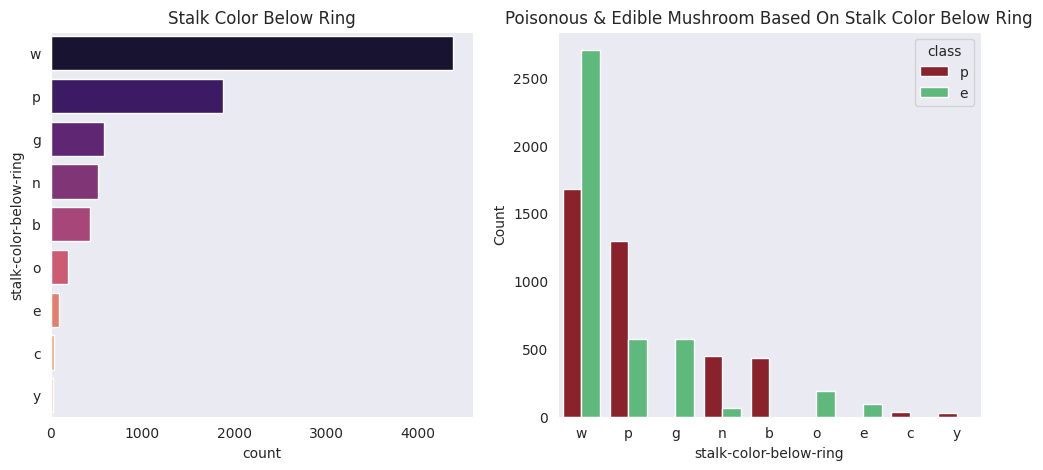

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['stalk-color-below-ring'], order=mushroom['stalk-color-below-ring'].value_counts().index, ax=axarr[0], palette="magma").set_title('Stalk Color Below Ring')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Stalk Color Below Ring')
b = sns.countplot(x="stalk-color-below-ring", data=mushroom, hue="class", order=mushroom['stalk-color-below-ring'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Veil Type

In [ ]:
mushroom.groupby(['veil-type'])['class'].value_counts().to_frame()

count
veil-type class       
p         e       4208
          p       3916

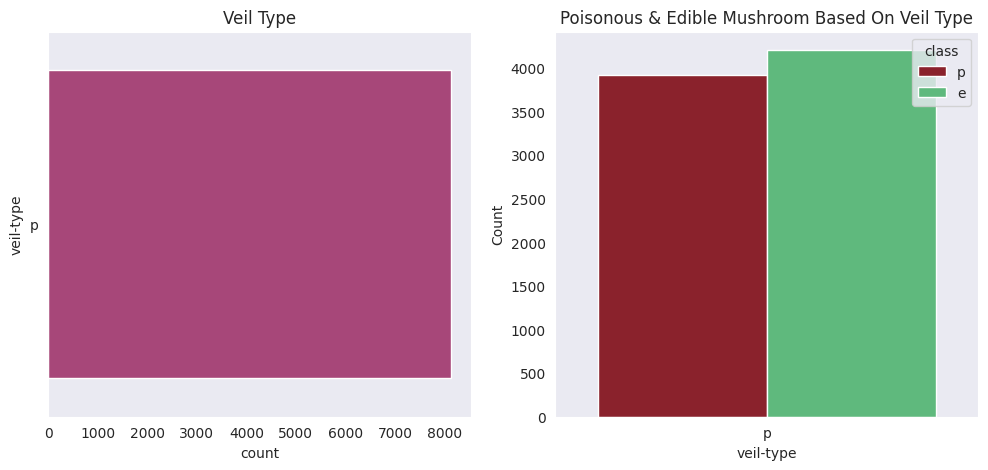

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['veil-type'], ax=axarr[0], palette="magma").set_title('Veil Type')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Veil Type')
b = sns.countplot(x="veil-type", data=mushroom, hue="class", palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')

#Veil Color

In [ ]:
mushroom.groupby(['veil-color'])['class'].value_counts().to_frame()

count
veil-color class       
n          e         96
o          e         96
w          e       4016
           p       3908
y          p          8

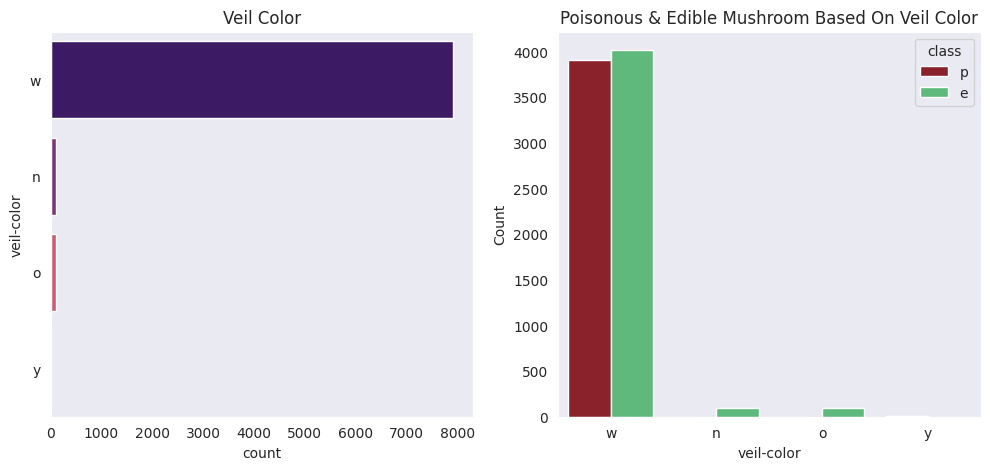

In [ ]:
fig, axarr = plt.subplots(1, 2, figsize=(12,5))
a = sns.countplot(mushroom['veil-color'], ax=axarr[0], order=mushroom['veil-color'].value_counts().index, palette="magma").set_title('Veil Color')
axarr[1].set_title('Poisonous & Edible Mushroom Based On Veil Color')
b = sns.countplot(x="veil-color", data=mushroom, hue="class", order=mushroom['veil-color'].value_counts().index, palette=('#9b111e','#50c878'), ax=axarr[1]).set_ylabel('Count')